# II) Taylor test

## 1) Principle
The aim is to check the sensitivity of the losses $f$ with respect to a local change of electric conductivity.
The test relies on Taylor expansion
$$f(\sigma + h \delta \sigma) = f(\sigma) + f'(\sigma)(\delta \sigma) h + O(|h|^2)  $$
so if the value of $f'$ is correct, the norm of Taylor remainder $|\mathcal T|$ should decrease quadratically with $|h|$
$$|\mathcal T| = f(\sigma + h \delta \sigma) - f(\sigma) - f'(\sigma)(\delta \sigma) h = O(|h|^2)  $$

___
## 2) Application to Joule losses

### 2.a) Setup

#### 2.a.i) Geometry
No need for a very refined mesh! The derivative expression should be independant of the mesh discretization. Moreover coarse mesh exhibits higher numerical errors, so if our gradient expression and computation are correct on a coarse mesh it would be even more accurate on a finer one.

In [1]:
from ngsolve.webgui import Draw
from utils.geometry import machine_mesh

polePairs = 6
bundles_per_half_slot = 5
mesh = machine_mesh(p=polePairs, 
                    bundles_per_half_slot=bundles_per_half_slot,
                    hAirgap = 1e-3,
                    hBundle=1e-3)
print(f"{mesh.nv} nodes, {mesh.ne} elements")
Draw(mesh, filename = "scenes/optim/taylor_tests/mesh.html")

2131 nodes, 4182 elements


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

#### 2.a.ii) Material properties

In [12]:
from utils.physics_symmetric import magnetization_halbach
from ngsolve import pi

mu0 = 4e-7*pi 
mur_iron = 1000
br = 1
sigma_copper = 6e7

M = mesh.MaterialCF({"rotor" : magnetization_halbach(br = br)})
nu = mesh.MaterialCF({"core_stator" : 1 / (mu0* mur_iron)}, default = 1/mu0)
sigma = mesh.MaterialCF({"slot(.*)_bundle.*" : sigma_copper})

#### 2.a.iii) Current supply

In [13]:
from utils.supply import phase_current, winding_arrangement, bundle_arrangement

freq = 1000
Irms = 100
phi = 0
winding_type =  "distributed" # "concentrated"

phase = phase_current(I_rms=Irms,  load_angle=phi)
winding = winding_arrangement(phase, type =winding_type)
bundles = bundle_arrangement(winding, bundles_per_half_slot=bundles_per_half_slot)

#### 2.a.iv) Finite element space

We define the type of FEM and its order. Higher order shape functions allow higher order curved mesh for improved accuracy.

In [14]:
curve_order = 2
fem_order = curve_order

In [15]:
from ngsolve import Periodic, H1
fes = Periodic( H1(mesh.Curve(curve_order), 
                   order = fem_order, 
                   dirichlet =  "shaft|out", 
                   complex = True),  [-1]*7 )

print(f"Number of degrees of freedom : {fes.ndof}")

Number of degrees of freedom : 5535


### 2.b) Definition of objective function and derivative

Then we define the objective function (AC losses).
From the numerical point of view, we might have problems with the quadrature order when evaluating integrals of high order polynomials. 

This quadrature order can be modified with `bonus_intorder`; default is 3, which leads to satisfying results of the Taylor tests.

In [16]:
bonus_intorder = 3 # default is 3, try with 0 to see the impact on error convergence of Taylor tests

In [17]:
from utils.physics_symmetric import solve_magnetoharmonic, solve_magnetoharmonic2, joule_losses, joule_losses2
from utils.optimization_symmetric import d_joule_losses, d_joule_losses2

def F_losses(sigma):
       """ Wrapper to return losses from conductivity sigma field """
       result = solve_magnetoharmonic(fes = fes, 
                        frequency = freq,
                        reluctivity = nu,
                        magnetization = M,
                        conductivity=sigma,
                        supply = bundles,
                        bonus_intorder = bonus_intorder)
       return joule_losses(result)   


def dF_losses(sigma):
       """ Wrapper to return gradient of losses from conductivity sigma field """
       result = solve_magnetoharmonic(fes = fes, 
                        frequency = freq,
                        reluctivity = nu,
                        magnetization = M,
                        conductivity=sigma,
                        supply = bundles,
                        bonus_intorder = bonus_intorder,
                        verbose = 1)
       return d_joule_losses(result, sigma, wrt = "conductivity", bonus_intorder = bonus_intorder)


def F_losses2(sigma):
       """ Wrapper to return losses from conductivity sigma field """
       result = solve_magnetoharmonic2(fes = fes, 
                        frequency = freq,
                        reluctivity = nu,
                        magnetization = M,
                        conductivity=sigma,
                        supply = bundles,
                        bonus_intorder = bonus_intorder)
       return joule_losses2(result)   


def dF_losses2(sigma):
       """ Wrapper to return gradient of losses from conductivity sigma field """
       result = solve_magnetoharmonic2(fes = fes, 
                        frequency = freq,
                        reluctivity = nu,
                        magnetization = M,
                        conductivity=sigma,
                        supply = bundles,
                        bonus_intorder = bonus_intorder,
                        verbose = 2)
       return d_joule_losses2(result, sigma, wrt = "conductivity", bonus_intorder = bonus_intorder)

### 2.c) Taylor tests

A loop is performed to compute $|\mathcal T|$ for different $|h|$ on a random perturbation $\delta \sigma$, chosen in a given space that can be $L^2(\Omega)$ (no continuity), or $H^1(\Omega)$ (imposed continuity).


In [ ]:
from utils.optimization_symmetric import taylor_test
from ngsolve import GridFunction, L2

# define the reference conductivity and its regularity (through its function space)
sigma_ref = GridFunction(L2(mesh, definedon = "slot(.*)_bundle.*"))  # L2 means sigma has no continuity
#sigma_ref = GridFunction(H1(mesh, definedon = "slot(.*)_bundle.*"))   # H1 ensures the continuity of sigma
sigma_ref.Set(sigma)

import numpy as np
seed = np.random.randint(10**5)
H, taylor_remainder, dF0, dF_estimated = taylor_test(F_losses,  dF_losses,  sigma_ref, seed = seed, H =  np.logspace(-9,-1,20), verbose = 2)
sigma_ref.Set(sigma)
H, taylor_remainder2, dF02, dF_estimated2 = taylor_test(F_losses2,  dF_losses2,  sigma_ref, seed = seed, H =  np.logspace(-9,-1,20), verbose = 2)



Compute reference F ...  done (564 ms) 
Generate perturbation ...  done (0 ms) 
Compute directional derivative ... -- START MAGNETOHARMONIC SOLVER --
Solver : pardiso
Setup function space...              done in 62 ms
Assemble matrix...                   done in 126 ms
Matrix decomposition with pardiso... done in 165 ms
Assemble right hand side...          done in 31 ms
Solve the problem...                 done in 5 ms
Pack the results...                  total time: 0.390 s
-- END MAGNETOHARMONIC SOLVER --
 done (1513 ms) 
it 0 / 20 (h =  1.00e-09) : ...  done (520 ms)
it 1 / 20 (h =  2.64e-09) : ...  done (581 ms)
it 2 / 20 (h =  6.95e-09) : ...  done (577 ms)
it 3 / 20 (h =  1.83e-08) : ...  done (665 ms)
it 4 / 20 (h =  4.83e-08) : ...  done (675 ms)
it 5 / 20 (h =  1.27e-07) : ...  done (561 ms)
it 6 / 20 (h =  3.36e-07) : ...  done (573 ms)
it 7 / 20 (h =  8.86e-07) : ...  done (581 ms)
it 8 / 20 (h =  2.34e-06) : ...  done (556 ms)
it 9 / 20 (h =  6.16e-06) : ...  done (554 ms)


Then we plot the norm of Taylor remainder and check its quadratic convergence with respect to $|h|$. The error curve is therefore parallel to $|h|^2$,  until floating point computation errors appear. Quadrature error might also appear before if the quadrature order is not high enough.

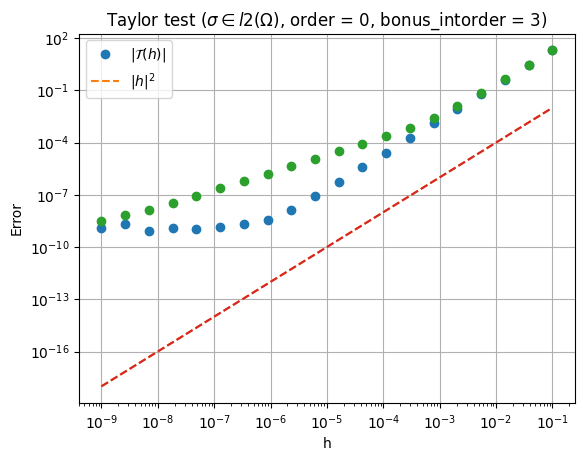

In [ ]:
# Display convergence of Taylor remainder
from utils.optimization_symmetric import plot_taylor_test
import matplotlib.pyplot as plt
plot_taylor_test(H, taylor_remainder); 
plot_taylor_test(H, taylor_remainder2); 
plt.grid()
plt.legend(["$|\\mathcal{T}(h)|$", "$|h|^2$"])
plt.title(f"Taylor test ($\\sigma \\in {sigma_ref.space.type[0:2]}(\\Omega)$, order = {sigma_ref.space.globalorder}, {bonus_intorder = })")
plt.savefig(f"scenes/optim/taylor_tests/taylor_test_{sigma_ref.space.type[0:2]}_order{sigma_ref.space.globalorder}_bonusintorder{bonus_intorder}.pdf")
plt.show()

We can also plot the convergence of directional derivative.

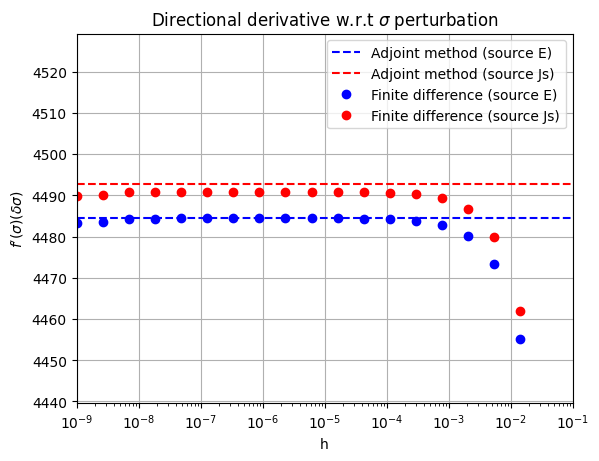

In [ ]:
# Display convergence of directional derivative to the value found by adjoint method
from numpy import array
plt.axhline(dF0, linestyle='--', color = "b", label = "Adjoint method (source E) ")
plt.axhline(dF02, linestyle='--', color = "r", label = "Adjoint method (source Js) ")
plt.semilogx(H, dF_estimated,'ob', label = "Finite difference (source E)")
plt.semilogx(H, dF_estimated2,'or', label = "Finite difference (source Js)")

min_error = min(abs(dF0-array(dF_estimated)))
plt.axis([H[0], H[-1], dF0 *0.99, dF0 * 1.01])
plt.title("Directional derivative w.r.t $\\sigma$ perturbation"); plt.legend()
plt.grid(); plt.xlabel("h"); plt.ylabel("$f'(\\sigma)(\\delta\\sigma)$")
plt.savefig(f"scenes/optim/taylor_tests/derivative_check_FD_{sigma_ref.space.type[0:2]}_order{sigma_ref.space.globalorder}_bonusintorder{bonus_intorder}.pdf")
plt.show()

___
## Summary 

We have checked the derivative expression, which can therefore be used in the following optimizations:
- [3_single_material_optimization](3_single_material_optimization.ipynb) (optimization of a unique conductivity for the whole winding)
- [4_multi_material_optimization](4_multi_material_optimization.ipynb) (optimization of a different conductivity for each bundle)
- [5_topology_optimization](5_topology_optimization.ipynb) (optimization of the conductivity at each point of the cross-section, so actually the cross-section itself)